# Visualizations


Views of data primarily taken from the shard `redux<yyyy>` files/folders.


## Bundle plot


Select sensor in the UI; plus NOON/MIDNIGHT.

In [1]:
# Jupyter cell version of the bundle plot visualization 
#   - dynamic sensor selection
#   - midnight / noon annotation
#   - sensor count
#     - 7/11 scalar (missing PAR, pH, pCO2, nitrate)
#     - 0/4 vector (no vel, spec.irr., oa, ba)

import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display
import numpy as np
from datetime import datetime, timedelta
import pandas as pd
import pytz

def get_input_with_default(prompt, default):
    """Get user input with default value."""
    response = input(f"{prompt} ").strip()
    return response if response else str(default)

# Oregon Slope Base timezone info
OREGON_TZ = pytz.timezone('America/Los_Angeles')

# Sensor configuration with colors that work well on white background
SENSORS = {
    'temperature': {'low': 7.0, 'high': 20.0, 'units': '°C', 'color': 'red'},
    'salinity': {'low': 32.0, 'high': 34.0, 'units': 'PSU', 'color': 'blue'},
    'density': {'low': 1024.0, 'high': 1028.0, 'units': 'kg/m³', 'color': 'black'},
    'dissolvedoxygen': {'low': 50.0, 'high': 300.0, 'units': 'µmol/kg', 'color': 'darkblue'},
    'cdom': {'low': 0.0, 'high': 2.5, 'units': 'ppb', 'color': 'brown'},
    'chlora': {'low': 0.0, 'high': 1.5, 'units': 'µg/L', 'color': 'green'},
    'backscatter': {'low': 0.0, 'high': 0.002, 'units': 'm⁻¹sr⁻¹', 'color': 'gray'}
}

# Get year range
start_year = int(get_input_with_default("Start year (default 2015):", "2015"))
end_year = int(get_input_with_default("End year (default 2016):", "2016"))

print(f"\nScanning redux folders from {start_year} to {end_year}...")
available_years = []
for year in range(start_year, end_year + 1):
    redux_dir = Path(f"~/ooi/redux/redux{year}").expanduser()
    if redux_dir.exists():
        profile_count = len(list(redux_dir.glob("*.nc")))
        if profile_count > 0:
            print(f"  redux{year}: {profile_count} profiles")
            available_years.append(year)

if not available_years:
    print("No years found")
else:
    print(f"\nUsing years: {available_years}")
    
    # Hardcoded to 2 sensors
    num_sensors = 2
    
    # Load profile files for all sensors
    all_profile_files = {}
    for sensor in SENSORS.keys():
        profile_files = []
        for year in available_years:
            redux_dir = Path(f"~/ooi/redux/redux{year}").expanduser()
            year_files = sorted(list(redux_dir.glob(f"*_{sensor}_*.nc")))
            profile_files.extend(year_files)
        all_profile_files[sensor] = profile_files
        print(f"{sensor}: {len(profile_files)} profiles")
    
    # Use the sensor with most profiles for indexing
    max_profiles = max(len(files) for files in all_profile_files.values())
    
    # Annotation data
    annotation_df = None
    annotation_enabled = False
    
    if max_profiles == 0:
        print("No profiles found")
    else:
        def extract_profile_info(filename):
            """Extract year, day, and profile number from filename."""
            parts = filename.stem.split('_')
            year = int(parts[4])
            doy = int(parts[5])
            profile_idx = int(parts[6])
            profile_num = int(parts[7])
            return year, doy, profile_idx, profile_num
        
        def check_time_gap(files, start_idx, end_idx):
            """Check if there's a >2 day gap between consecutive profiles."""
            if len(files) == 0 or start_idx >= len(files):
                return False
            for i in range(start_idx, min(end_idx - 1, len(files) - 1)):
                parts1 = files[i].stem.split('_')
                parts2 = files[i + 1].stem.split('_')
                
                year1, doy1 = int(parts1[4]), int(parts1[5])
                year2, doy2 = int(parts2[4]), int(parts2[5])
                
                date1 = datetime(year1, 1, 1) + timedelta(days=doy1 - 1)
                date2 = datetime(year2, 1, 1) + timedelta(days=doy2 - 1)
                
                if (date2 - date1).days > 2:
                    return True
            return False
        
        def check_noon_midnight(ds):
            """Check if profile spans local noon or midnight."""
            try:
                start_time = pd.to_datetime(ds.time.values[0])
                end_time = pd.to_datetime(ds.time.values[-1])
                peak_time = pd.to_datetime(ds.time.values[len(ds.time.values)//2])
                
                start_local = start_time.tz_localize('UTC').astimezone(OREGON_TZ)
                end_local = end_time.tz_localize('UTC').astimezone(OREGON_TZ)
                peak_local = peak_time.tz_localize('UTC').astimezone(OREGON_TZ)
                
                window_start = start_local - timedelta(minutes=30)
                window_end = end_local + timedelta(minutes=30)
                
                local_midnight = start_local.replace(hour=0, minute=0, second=0, microsecond=0)
                local_noon = start_local.replace(hour=12, minute=0, second=0, microsecond=0)
                
                if window_start <= local_midnight <= window_end:
                    return 'MIDNIGHT', peak_local
                
                if window_start <= local_noon <= window_end:
                    return 'NOON', peak_local
                    
            except Exception as e:
                print(f"Error in check_noon_midnight: {e}")
            
            return None, None
        
        def plot_bundle(sensor1, sensor2, low1, high1, mode1, low2, high2, mode2, nProfiles, index0):
            """Plot a bundle of consecutive profiles."""
            
            if nProfiles == 0:
                plt.figure(figsize=(10.2, 6.8))
                plt.text(0.5, 0.5, 'Select nProfiles > 0', ha='center', va='center', transform=plt.gca().transAxes)
                plt.show()
                return
            
            start_idx = index0 - 1
            end_idx = min(start_idx + nProfiles, max_profiles)
            
            if start_idx >= max_profiles:
                plt.figure(figsize=(10.2, 6.8))
                plt.text(0.5, 0.5, f'Index {index0} exceeds available profiles', ha='center', va='center', transform=plt.gca().transAxes)
                plt.show()
                return
            
            # Get selected sensors
            selected_sensors = [sensor1, sensor2]
            sensor_configs = [
                {'name': sensor1, 'low': low1, 'high': high1, 'units': SENSORS[sensor1]['units'], 
                 'color': SENSORS[sensor1]['color'], 'mode': mode1},
                {'name': sensor2, 'low': low2, 'high': high2, 'units': SENSORS[sensor2]['units'], 
                 'color': SENSORS[sensor2]['color'], 'mode': mode2}
            ]
            
            # Create figure with 85% of original size (12x8 -> 10.2x6.8)
            fig, ax1 = plt.subplots(figsize=(10.2, 6.8))
            ax2 = ax1.twiny()
            axes = [ax1, ax2]
            
            # Check for time gap
            first_sensor_files = all_profile_files[sensor1]
            has_time_gap = check_time_gap(first_sensor_files, start_idx, end_idx)
            
            # Check for noon/midnight if single profile
            noon_midnight_label = None
            peak_time_local = None
            current_profile_idx = None
            if nProfiles == 1 and start_idx < len(first_sensor_files):
                try:
                    ds = xr.open_dataset(first_sensor_files[start_idx])
                    noon_midnight_label, peak_time_local = check_noon_midnight(ds)
                    _, _, current_profile_idx, _ = extract_profile_info(first_sensor_files[start_idx])
                except Exception:
                    pass
            
            # Plot each sensor
            for sensor_idx, (sensor, config, ax) in enumerate(zip(selected_sensors, sensor_configs, axes)):
                profile_files = all_profile_files[sensor]
                
                if config['mode'] == 'bundle':
                    for i in range(start_idx, min(end_idx, len(profile_files))):
                        try:
                            ds = xr.open_dataset(profile_files[i])
                            sensor_data = ds[sensor].values
                            depth = ds['depth'].values
                            
                            valid_mask = ~(np.isnan(sensor_data) | np.isnan(depth))
                            if np.any(valid_mask):
                                data_clean = sensor_data[valid_mask]
                                depth_clean = depth[valid_mask]
                                ax.plot(data_clean, depth_clean, '-', color=config['color'], markersize=1, alpha=0.6, linewidth=1)
                        except Exception:
                            continue
                else:
                    depth_grid = np.linspace(0, 200, 200)
                    interpolated_data = []
                    
                    for i in range(start_idx, min(end_idx, len(profile_files))):
                        try:
                            ds = xr.open_dataset(profile_files[i])
                            sensor_data = ds[sensor].values
                            depth = ds['depth'].values
                            
                            valid_mask = ~(np.isnan(sensor_data) | np.isnan(depth))
                            if np.any(valid_mask) and len(depth[valid_mask]) > 1:
                                depth_clean = depth[valid_mask]
                                data_clean = sensor_data[valid_mask]
                                
                                sort_idx = np.argsort(depth_clean)
                                depth_sorted = depth_clean[sort_idx]
                                data_sorted = data_clean[sort_idx]
                                
                                interp_data = np.interp(depth_grid, depth_sorted, data_sorted, left=np.nan, right=np.nan)
                                
                                if np.any(~np.isnan(interp_data)):
                                    interpolated_data.append(interp_data)
                        except Exception:
                            continue
                    
                    if len(interpolated_data) >= 2:
                        data_array = np.array(interpolated_data)
                        valid_counts = np.sum(~np.isnan(data_array), axis=0)
                        
                        if np.any(valid_counts >= 2):
                            mask = valid_counts >= 2
                            mean = np.full(len(depth_grid), np.nan)
                            std = np.full(len(depth_grid), np.nan)
                            
                            mean[mask] = np.nanmean(data_array[:, mask], axis=0)
                            std[mask] = np.nanstd(data_array[:, mask], axis=0)
                            
                            valid = ~np.isnan(mean)
                            if np.any(valid):
                                ax.plot(mean[valid], depth_grid[valid], '-', color='black', linewidth=3)
                                ax.plot((mean + std)[valid], depth_grid[valid], '-', color='black', linewidth=1, alpha=0.7)
                                ax.plot((mean - std)[valid], depth_grid[valid], '-', color='black', linewidth=1, alpha=0.7)
                    elif len(interpolated_data) == 1:
                        data_array = np.array(interpolated_data)
                        mean = data_array[0]
                        valid = ~np.isnan(mean)
                        if np.any(valid):
                            ax.plot(mean[valid], depth_grid[valid], '-', color='black', linewidth=3)
                
                # Plot annotations if enabled
                if annotation_enabled and annotation_df is not None and nProfiles == 1 and current_profile_idx is not None:
                    sensor_annotations = annotation_df[
                        (annotation_df['shard'] == sensor) & 
                        (annotation_df['profile'] == current_profile_idx)
                    ]
                    
                    for _, row in sensor_annotations.iterrows():
                        try:
                            depth_val = row.get('depth', 180)
                            if pd.isna(depth_val):
                                depth_val = 180
                            
                            value_val = row.get('value', np.nan)
                            text_val = row.get('text', '')
                            
                            if pd.notna(text_val) and text_val:
                                if pd.notna(value_val):
                                    ax.text(value_val, depth_val, text_val, fontsize=10, ha='center')
                            else:
                                if pd.isna(value_val):
                                    continue
                                
                                color_val = row.get('color', config['color'])
                                if pd.isna(color_val):
                                    color_val = config['color']
                                
                                markersize_val = row.get('markersize', 9)
                                if pd.isna(markersize_val):
                                    markersize_val = 9
                                
                                opacity_val = row.get('opacity', 1.0)
                                if pd.isna(opacity_val):
                                    opacity_val = 1.0
                                
                                ax.plot(value_val, depth_val, 'o', color=color_val, 
                                       markersize=markersize_val, alpha=opacity_val)
                        except Exception as e:
                            print(f"Error rendering annotation: {e}")
                
                # Set up axes
                ax.set_xlabel(f'{config["name"].capitalize()} ({config["units"]})', fontsize=12, color=config['color'])
                ax.set_xlim(config['low'], config['high'])
                ax.tick_params(axis='x', labelcolor=config['color'])
                
                if sensor_idx == 1:
                    ax.xaxis.set_label_position('top')
            
            # Set y-axis
            ax1.set_ylabel('Depth (m)', fontsize=12)
            ax1.set_ylim(200, 0)
            ax1.grid(True, alpha=0.3)
            
            # Add Time Gap warning
            if has_time_gap:
                ax1.text(0.95, 0.05, 'Time Gap', transform=ax1.transAxes,
                       fontsize=20, fontweight='bold', ha='right', va='bottom',
                       bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=2))
            
            # Add NOON/MIDNIGHT label
            if noon_midnight_label:
                label_text = f"{noon_midnight_label}\n{peak_time_local.strftime('%H:%M:%S')}"
                ax1.text(0.95, 0.15, label_text, transform=ax1.transAxes,
                       fontsize=20, fontweight='bold', ha='right', va='bottom')
           
            # Title
            if len(first_sensor_files) > start_idx:
                year, doy, profile_idx, profile_num = extract_profile_info(first_sensor_files[start_idx])
                if nProfiles == 1:
                    title = f'{year}-{doy:03d}-{profile_num}'
                else:
                    last_idx = min(end_idx - 1, len(first_sensor_files) - 1)
                    last_year, last_doy, _, last_profile_num = extract_profile_info(first_sensor_files[last_idx])
                    title = f'{year}-{doy:03d}-{profile_num} to {last_year}-{last_doy:03d}-{last_profile_num}'
                fig.suptitle(title, fontsize=14)
            
            plt.tight_layout()
            plt.show()
        
        def load_annotations(b):
            """Load annotation file."""
            global annotation_df, annotation_enabled
            
            annotation_file = annotation_path.value.strip()
            if not annotation_file:
                print("No annotation file specified")
                return
            
            try:
                file_path = Path(annotation_file).expanduser()
                if not file_path.exists():
                    print(f"File not found: {file_path}")
                    return
                
                df = pd.read_csv(file_path)
                
                required_cols = ['shard', 'profile', 'depth', 'value', 'color', 'markersize', 'opacity', 'text']
                missing_cols = [col for col in required_cols if col not in df.columns]
                
                if missing_cols:
                    print(f"Missing required columns: {missing_cols}")
                    return
                
                if df['shard'].isna().any() or df['profile'].isna().any():
                    print("Error: shard and profile fields cannot be empty")
                    return
                
                annotation_df = df
                annotation_enabled = not annotation_enabled
                
                if annotation_enabled:
                    print(f"Annotations loaded and enabled: {len(df)} rows")
                    annotation_btn.description = "Annotation: ON"
                else:
                    print("Annotations disabled")
                    annotation_btn.description = "Annotation: OFF"
                
            except Exception as e:
                print(f"Error loading annotations: {e}")
        
        # Create sensor selection dropdowns
        sensor_list = list(SENSORS.keys())
        sensor1_dropdown = widgets.Dropdown(options=sensor_list, value='temperature', description='Sensor 1:')
        sensor2_dropdown = widgets.Dropdown(options=sensor_list, value='salinity', description='Sensor 2:')
        
        # Range sliders and mode toggle for sensor 1
        low1_slider = widgets.FloatSlider(value=SENSORS['temperature']['low'], min=0, max=SENSORS['temperature']['high'], 
                                          step=SENSORS['temperature']['high']/100, description='Sensor 1 low:', 
                                          continuous_update=False, readout_format='.3f')
        high1_slider = widgets.FloatSlider(value=SENSORS['temperature']['high'], min=SENSORS['temperature']['high']/2, 
                                           max=2*SENSORS['temperature']['high'], step=SENSORS['temperature']['high']/100,
                                           description='Sensor 1 high:', continuous_update=False, readout_format='.3f')
        mode1_toggle = widgets.ToggleButtons(options=['bundle', 'meanstd'], value='bundle', description='Sensor 1 mode:')
        
        # Range sliders and mode toggle for sensor 2
        low2_slider = widgets.FloatSlider(value=SENSORS['salinity']['low'], min=0, max=SENSORS['salinity']['high'],
                                          step=SENSORS['salinity']['high']/100, description='Sensor 2 low:', 
                                          continuous_update=False, readout_format='.3f')
        high2_slider = widgets.FloatSlider(value=SENSORS['salinity']['high'], min=SENSORS['salinity']['high']/2, 
                                           max=2*SENSORS['salinity']['high'], step=SENSORS['salinity']['high']/100,
                                           description='Sensor 2 high:', continuous_update=False, readout_format='.3f')
        mode2_toggle = widgets.ToggleButtons(options=['bundle', 'meanstd'], value='bundle', description='Sensor 2 mode:')
        
        # Profile navigation sliders
        nProfiles_slider = widgets.IntSlider(value=1, min=0, max=180, step=1, description='nProfiles:', continuous_update=True)
        index0_slider = widgets.IntSlider(value=1, min=1, max=max_profiles, step=1, description='index0:', continuous_update=True)
        
        # Update slider ranges when sensor selection changes
        def update_sensor1_sliders(change):
            sensor = change['new']
            low1_slider.value = SENSORS[sensor]['low']
            low1_slider.min = 0
            low1_slider.max = SENSORS[sensor]['high']
            low1_slider.step = SENSORS[sensor]['high'] / 100
            high1_slider.value = SENSORS[sensor]['high']
            high1_slider.min = SENSORS[sensor]['high'] / 2
            high1_slider.max = 2 * SENSORS[sensor]['high']
            high1_slider.step = SENSORS[sensor]['high'] / 100
        
        def update_sensor2_sliders(change):
            sensor = change['new']
            low2_slider.value = SENSORS[sensor]['low']
            low2_slider.min = 0
            low2_slider.max = SENSORS[sensor]['high']
            low2_slider.step = SENSORS[sensor]['high'] / 100
            high2_slider.value = SENSORS[sensor]['high']
            high2_slider.min = SENSORS[sensor]['high'] / 2
            high2_slider.max = 2 * SENSORS[sensor]['high']
            high2_slider.step = SENSORS[sensor]['high'] / 100
        
        sensor1_dropdown.observe(update_sensor1_sliders, names='value')
        sensor2_dropdown.observe(update_sensor2_sliders, names='value')
        
        # Annotation widgets
        annotation_path = widgets.Text(value='', placeholder='~/argosy/annotation.csv', description='Annotation file:', 
                                       style={'description_width': 'initial'})
        annotation_btn = widgets.Button(description='Annotation: OFF')
        annotation_btn.on_click(load_annotations)
        
        # Navigation buttons
        def on_minus_minus(b):
            step = max(1, nProfiles_slider.value // 2)
            index0_slider.value = max(1, index0_slider.value - step)
        
        def on_minus(b):
            index0_slider.value = max(1, index0_slider.value - 1)
        
        def on_plus(b):
            index0_slider.value = min(max_profiles, index0_slider.value + 1)
        
        def on_plus_plus(b):
            step = max(1, nProfiles_slider.value // 2)
            index0_slider.value = min(max_profiles, index0_slider.value + step)
        
        btn_minus_minus = widgets.Button(description='--')
        btn_minus = widgets.Button(description='-')
        btn_plus = widgets.Button(description='+')
        btn_plus_plus = widgets.Button(description='++')
        
        btn_minus_minus.on_click(on_minus_minus)
        btn_minus.on_click(on_minus)
        btn_plus.on_click(on_plus)
        btn_plus_plus.on_click(on_plus_plus)
        
        nav_buttons = widgets.HBox([btn_minus_minus, btn_minus, btn_plus, btn_plus_plus])
        annotation_box = widgets.HBox([annotation_path, annotation_btn])
        
        # Create interactive plot with nProfiles and index0 at the end
        interactive_plot = widgets.interactive(plot_bundle, 
                                               sensor1=sensor1_dropdown, sensor2=sensor2_dropdown,
                                               low1=low1_slider, high1=high1_slider, mode1=mode1_toggle,
                                               low2=low2_slider, high2=high2_slider, mode2=mode2_toggle,
                                               nProfiles=nProfiles_slider, index0=index0_slider)
        
        # Display widgets
        display(interactive_plot)
        display(nav_buttons)
        display(annotation_box)


Start year (default 2015):  2020
End year (default 2016):  2022



Scanning redux folders from 2020 to 2022...
  redux2020: 10115 profiles
  redux2021: 22190 profiles
  redux2022: 17958 profiles

Using years: [2020, 2021, 2022]
temperature: 6164 profiles
salinity: 6164 profiles
density: 6164 profiles
dissolvedoxygen: 6164 profiles
cdom: 6556 profiles
chlora: 6556 profiles
backscatter: 6556 profiles


interactive(children=(Dropdown(description='Sensor 1:', options=('temperature', 'salinity', 'density', 'dissol…

Found 9 profiles for 2016-002


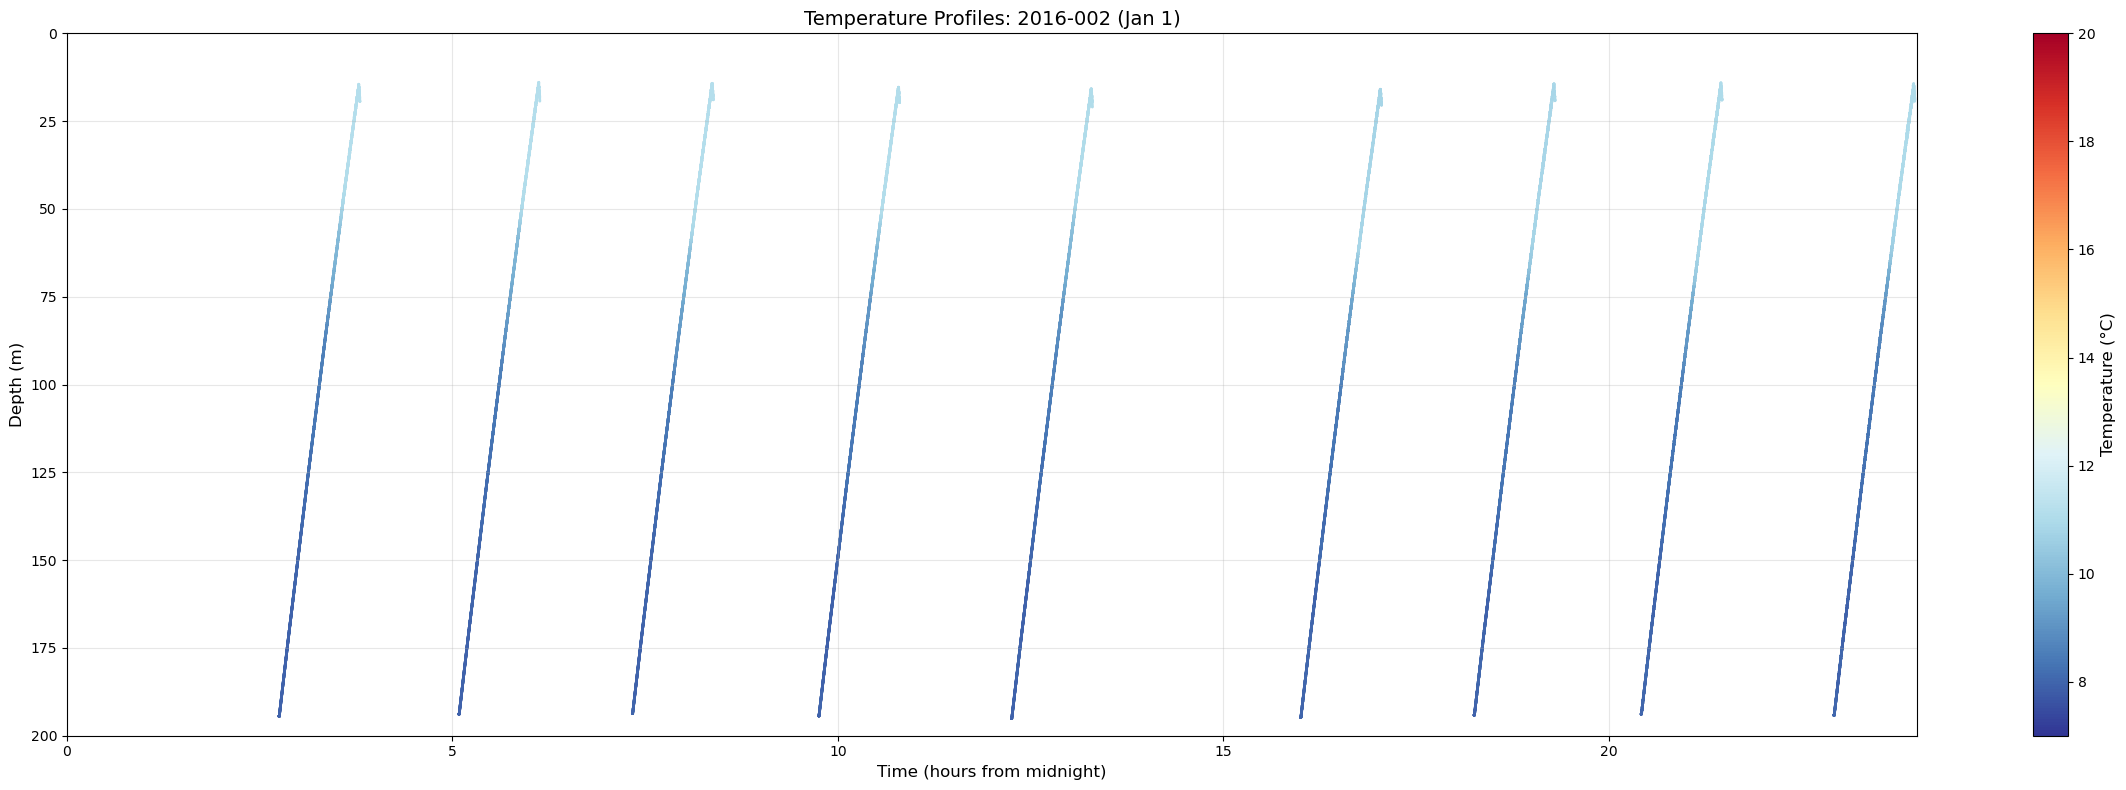

In [2]:
# examine single days to identify midnight and noon profiles

import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta

# Get temperature profiles for Jan 1, 2016 (day 1)
redux_dir = Path("~/ooi/redux/redux2016").expanduser()
temp_files = sorted(list(redux_dir.glob("*_temperature_2016_002_*.nc")))

print(f"Found {len(temp_files)} profiles for 2016-002")

if len(temp_files) > 0:
    # Create very wide figure
    fig, ax = plt.subplots(figsize=(24, 8))
    
    # Collect all time and depth data
    for f in temp_files:
        ds = xr.open_dataset(f)
        temp = ds['temperature'].values
        depth = ds['depth'].values
        time = ds['time'].values
        
        # Convert time to matplotlib format
        time_numeric = [(t - np.datetime64('2016-01-02T00:00:00')) / np.timedelta64(1, 'h') for t in time]
        
        # Plot temperature as color-coded scatter
        sc = ax.scatter(time_numeric, depth, c=temp, cmap='RdYlBu_r', s=1, vmin=7, vmax=20)
    
    ax.set_xlabel('Time (hours from midnight)', fontsize=12)
    ax.set_ylabel('Depth (m)', fontsize=12)
    ax.set_ylim(200, 0)
    ax.set_xlim(0, 24)
    ax.grid(True, alpha=0.3)
    ax.set_title('Temperature Profiles: 2016-002 (Jan 1)', fontsize=14)
    
    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Temperature (°C)', fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("No profiles found for 2016-001")

    

## Curtain plot


Processing Salinity...

  Found 4629 salinity shard files
  Pass 1: scanning salinity range...
    9% (462/4629)
    19% (924/4629)
    29% (1386/4629)
    39% (1848/4629)
    49% (2310/4629)
    59% (2772/4629)
    69% (3234/4629)
    79% (3696/4629)
    89% (4158/4629)
    99% (4620/4629)
  salinity central 90% range: 32.012 to 33.884
  Pass 2: building curtain data...
    9% (462/4629)
    19% (924/4629)
    29% (1386/4629)
    39% (1848/4629)
    49% (2310/4629)
    59% (2772/4629)
    69% (3234/4629)
    79% (3696/4629)
    89% (4158/4629)
    99% (4620/4629)
  Profiles with data: 4629
  Time gaps > 12h: 25, total columns: 4679

Processing Temperature...

  Found 4629 temperature shard files
  Pass 1: scanning temperature range...
    9% (462/4629)
    19% (924/4629)
    29% (1386/4629)
    39% (1848/4629)
    49% (2310/4629)
    59% (2772/4629)
    69% (3234/4629)
    79% (3696/4629)
    89% (4158/4629)
    99% (4620/4629)
  temperature central 90% range: 7.395 to 13.529
  Pass 

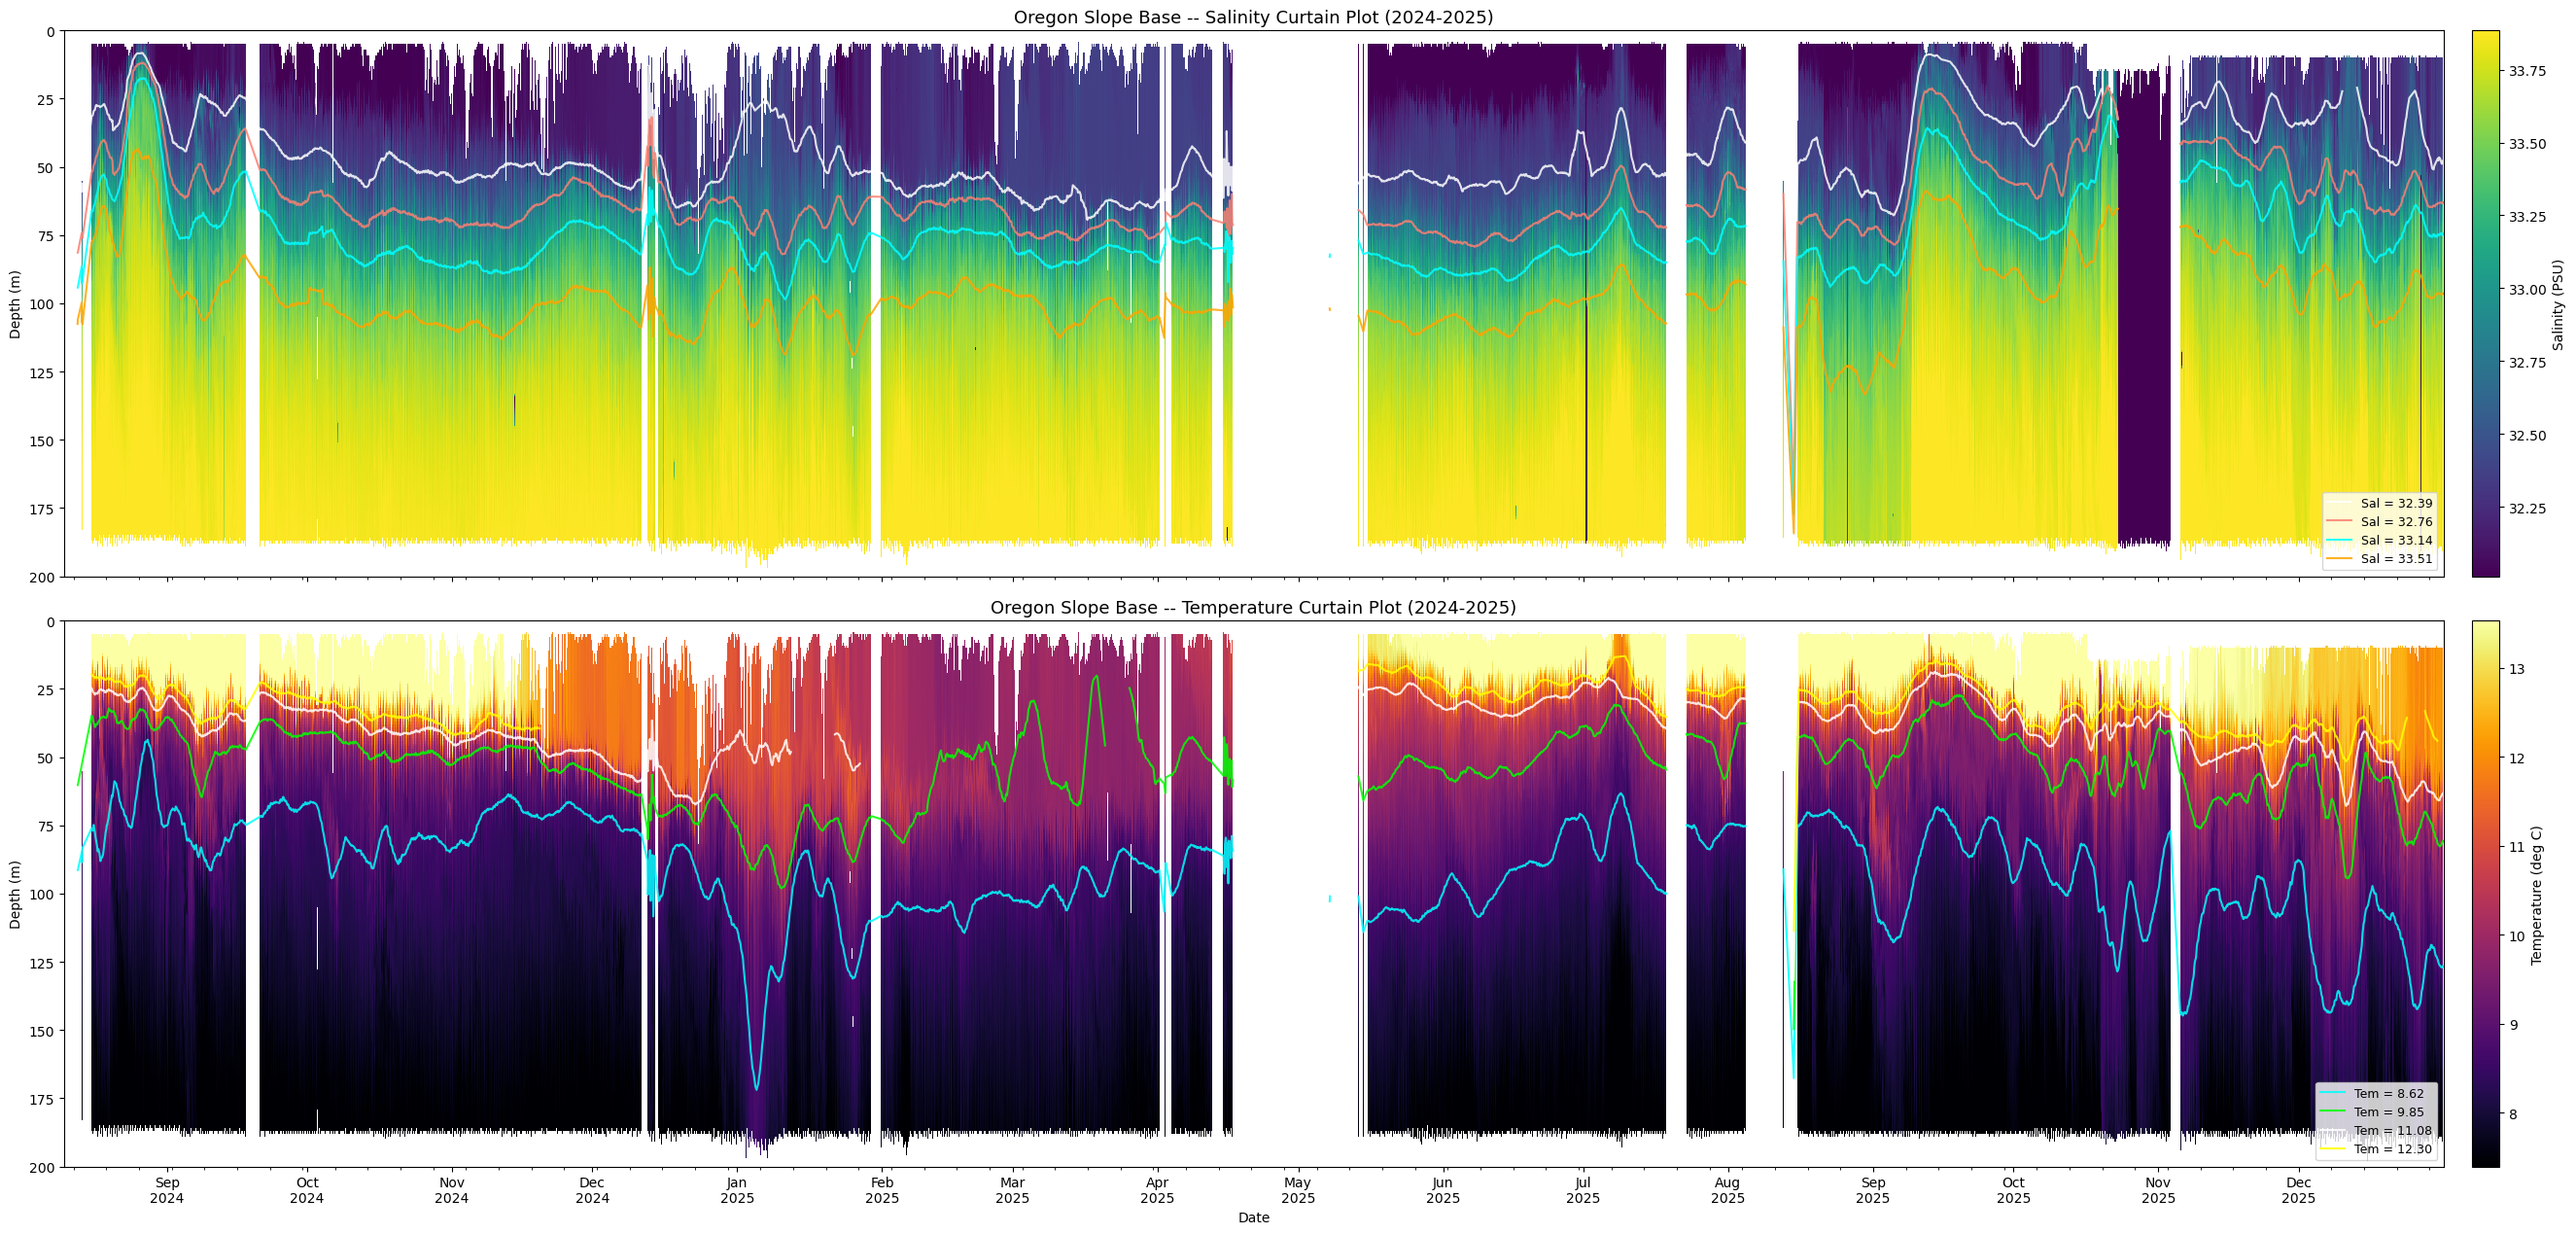

In [7]:
"""
Curtain plots: Salinity and Temperature for Oregon Slope Base shallow profiler.
Two stacked panels, Aug 10 2024 through Dec 31 2025.
Color encodes data over the central 90% of each sensor's dynamic range.
Contour line overlays: 4 lines per panel, low-pass filtered.
Contour lines are broken at gaps >= 3 days.
White background where no profile data exists.

Runs in a Jupyter cell (Visualizations.ipynb).
"""

import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from scipy.ndimage import uniform_filter1d

# == Config ====================================================================
REDUX_DIRS    = ["/home/rob/ooi/redux/redux2024", "/home/rob/ooi/redux/redux2025"]
DEPTH_MIN     = 0
DEPTH_MAX     = 200
DEPTH_BINS    = 200
TIME_START    = datetime(2024, 8, 10)
TIME_END      = datetime(2025, 12, 31, 23, 59, 59)
OUTPUT_PNG    = "/home/rob/argosy/chapters/curtain_salinity_2024_2025.png"
GAP_HOURS     = 12
N_CONTOURS    = 4
LP_WINDOW     = 27
CONTOUR_GAP_DAYS = 3        # break contour lines at gaps >= this many days

SENSORS = [
    {"glob": "RCA_sb_sp_salinity_*.nc",    "var": "salinity",    "label": "Salinity (PSU)",
     "cmap": "viridis", "contour_colors": ["white", "salmon", "cyan", "orange"], "title_var": "Salinity"},
    {"glob": "RCA_sb_sp_temperature_*.nc", "var": "temperature", "label": "Temperature (deg C)",
     "cmap": "inferno",  "contour_colors": ["cyan", "lime", "white", "yellow"],  "title_var": "Temperature"},
]

depth_edges   = np.linspace(DEPTH_MIN, DEPTH_MAX, DEPTH_BINS + 1)
depth_centers = 0.5 * (depth_edges[:-1] + depth_edges[1:])
gap_threshold = np.timedelta64(GAP_HOURS, 'h')
contour_gap_threshold = np.timedelta64(CONTOUR_GAP_DAYS, 'D')
bins_range    = np.arange(DEPTH_BINS)


# == Helper: build curtain data for one sensor =================================
def build_curtain(shard_glob, var_name):
    files = []
    for d in REDUX_DIRS:
        files.extend(sorted(glob.glob(f"{d}/{shard_glob}")))
    n_files = len(files)
    print(f"\n  Found {n_files} {var_name} shard files")
    report_interval = max(1, n_files // 10)

    # Pass 1: data range
    print(f"  Pass 1: scanning {var_name} range...")
    all_vals = []
    for i, f in enumerate(files):
        if (i + 1) % report_interval == 0:
            print(f"    {100 * (i + 1) // n_files}% ({i + 1}/{n_files})")
        ds = xr.open_dataset(f)
        v = ds[var_name].values
        d = ds["depth"].values
        mask = (d >= DEPTH_MIN) & (d <= DEPTH_MAX) & np.isfinite(v)
        all_vals.append(v[mask])
        ds.close()
    all_vals = np.concatenate(all_vals)
    vmin = np.nanpercentile(all_vals, 5)
    vmax = np.nanpercentile(all_vals, 95)
    print(f"  {var_name} central 90% range: {vmin:.3f} to {vmax:.3f}")
    del all_vals

    # Pass 2: build columns
    print(f"  Pass 2: building curtain data...")
    profile_columns = []
    for i, f in enumerate(files):
        if (i + 1) % report_interval == 0:
            print(f"    {100 * (i + 1) // n_files}% ({i + 1}/{n_files})")
        ds = xr.open_dataset(f)
        t = ds["time"].values
        d = ds["depth"].values
        v = ds[var_name].values
        ds.close()
        mask = (d >= DEPTH_MIN) & (d <= DEPTH_MAX) & np.isfinite(v)
        if mask.sum() == 0:
            continue
        d_m, v_m, t_m = d[mask], v[mask], t[mask]
        mean_time = t_m[0] + (t_m[-1] - t_m[0]) / 2
        col = np.full(DEPTH_BINS, np.nan)
        bin_idx = np.digitize(d_m, depth_edges) - 1
        for bi in bins_range:
            vals = v_m[bin_idx == bi]
            if len(vals) > 0:
                col[bi] = np.nanmean(vals)
        profile_columns.append((mean_time, col))

    print(f"  Profiles with data: {len(profile_columns)}")
    profile_columns.sort(key=lambda x: x[0])
    return profile_columns, vmin, vmax


# == Helper: compute and filter contour lines ==================================
def compute_contours(profile_columns, vmin, vmax):
    contour_values = np.linspace(vmin, vmax, N_CONTOURS + 2)[1:-1]
    raw_times = np.array([pc[0] for pc in profile_columns])
    raw_curtain = np.column_stack([pc[1] for pc in profile_columns])

    gap_mask = np.ones(len(raw_times), dtype=bool)
    for j in range(1, len(raw_times)):
        if (raw_times[j] - raw_times[j - 1]) > gap_threshold:
            gap_mask[j] = False

    contour_filtered = {}
    for sv in contour_values:
        depths_at_sv = np.full(len(profile_columns), np.nan)
        for j in range(len(profile_columns)):
            col = raw_curtain[:, j]
            valid_mask = np.isfinite(col)
            if valid_mask.sum() < 2:
                continue
            dc = depth_centers[valid_mask]
            sc = col[valid_mask]
            crossings = np.where(np.diff(np.sign(sc - sv)))[0]
            if len(crossings) > 0:
                k = crossings[0]
                s0, s1 = sc[k], sc[k + 1]
                d0, d1 = dc[k], dc[k + 1]
                if s1 != s0:
                    depths_at_sv[j] = d0 + (sv - s0) * (d1 - d0) / (s1 - s0)

        filtered = depths_at_sv.copy()
        seg_start = 0
        for j in range(1, len(filtered) + 1):
            if j == len(filtered) or not gap_mask[j]:
                seg = filtered[seg_start:j]
                valid = np.isfinite(seg)
                if valid.sum() >= LP_WINDOW:
                    indices = np.arange(len(seg))
                    seg_interp = np.interp(indices, indices[valid], seg[valid])
                    seg_smooth = uniform_filter1d(seg_interp, size=LP_WINDOW)
                    seg_smooth[~valid] = np.nan
                    filtered[seg_start:j] = seg_smooth
                seg_start = j
        contour_filtered[sv] = filtered

    return contour_values, raw_times, contour_filtered


# == Helper: insert NaN gap columns ============================================
def insert_gaps(profile_columns):
    expanded = [profile_columns[0]]
    gaps_found = 0
    for j in range(1, len(profile_columns)):
        t_prev = profile_columns[j - 1][0]
        t_curr = profile_columns[j][0]
        if (t_curr - t_prev) > gap_threshold:
            nan_col = np.full(DEPTH_BINS, np.nan)
            expanded.append((t_prev + np.timedelta64(1, 'h'), nan_col))
            expanded.append((t_curr - np.timedelta64(1, 'h'), nan_col))
            gaps_found += 1
        expanded.append(profile_columns[j])
    print(f"  Time gaps > {GAP_HOURS}h: {gaps_found}, total columns: {len(expanded)}")
    times = np.array([pc[0] for pc in expanded])
    curtain = np.column_stack([pc[1] for pc in expanded])
    return times, curtain


# == Helper: plot contour line with gap breaks =================================
def plot_contour_segments(ax, raw_times, depths, color, label):
    """Plot a contour line, breaking it at gaps >= CONTOUR_GAP_DAYS."""
    valid = np.isfinite(depths)
    indices = np.where(valid)[0]
    if len(indices) == 0:
        return

    # Split into segments at time gaps
    segments = []
    seg_start = 0
    for k in range(1, len(indices)):
        i_prev = indices[k - 1]
        i_curr = indices[k]
        if (raw_times[i_curr] - raw_times[i_prev]) >= contour_gap_threshold:
            segments.append(indices[seg_start:k])
            seg_start = k
    segments.append(indices[seg_start:])

    # Plot each segment; only label the first one for the legend
    for s_idx, seg in enumerate(segments):
        if len(seg) < 2:
            continue
        t_mpl = mdates.date2num(raw_times[seg].astype("datetime64[us]").astype(datetime))
        lbl = label if s_idx == 0 else None
        ax.plot(t_mpl, depths[seg], color=color, linewidth=1.5, alpha=0.85, label=lbl)


# == Build data for both sensors ===============================================
sensor_data = []
for sensor in SENSORS:
    print(f"\n{'='*60}\nProcessing {sensor['title_var']}...")
    pcols, vmin, vmax = build_curtain(sensor["glob"], sensor["var"])
    contour_values, raw_times, contour_filtered = compute_contours(pcols, vmin, vmax)
    times, curtain = insert_gaps(pcols)
    sensor_data.append({
        "times": times, "curtain": curtain,
        "vmin": vmin, "vmax": vmax,
        "contour_values": contour_values, "raw_times": raw_times,
        "contour_filtered": contour_filtered, "sensor": sensor,
    })


# == Plot: two stacked panels ==================================================
fig, axes = plt.subplots(2, 1, figsize=(30, 12.8), sharex=True)

for ax, sd in zip(axes, sensor_data):
    sensor = sd["sensor"]
    times_mpl = mdates.date2num(sd["times"].astype("datetime64[us]").astype(datetime))

    dt_half = np.diff(times_mpl) / 2
    time_edges = np.empty(len(times_mpl) + 1)
    time_edges[0]    = times_mpl[0] - (dt_half[0] if len(dt_half) > 0 else 0.01)
    time_edges[-1]   = times_mpl[-1] + (dt_half[-1] if len(dt_half) > 0 else 0.01)
    time_edges[1:-1] = times_mpl[:-1] + dt_half

    pcm = ax.pcolormesh(time_edges, depth_edges, sd["curtain"],
                         cmap=sensor["cmap"], vmin=sd["vmin"], vmax=sd["vmax"],
                         shading="flat")

    # Overlay contour lines with gap breaks
    for idx, sv in enumerate(sd["contour_values"]):
        fd = sd["contour_filtered"][sv]
        color = sensor["contour_colors"][idx % len(sensor["contour_colors"])]
        label = f"{sensor['title_var'][:3]} = {sv:.2f}"
        plot_contour_segments(ax, sd["raw_times"], fd, color, label)

    ax.legend(loc="lower right", fontsize=9, framealpha=0.8)
    ax.set_ylim(DEPTH_MAX, DEPTH_MIN)
    ax.set_xlim(mdates.date2num(TIME_START), mdates.date2num(TIME_END))
    ax.set_ylabel("Depth (m)")
    ax.set_title(f"Oregon Slope Base -- {sensor['title_var']} Curtain Plot (2024-2025)", fontsize=13)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))

    cbar = fig.colorbar(pcm, ax=ax, pad=0.01)
    cbar.set_label(sensor["label"])

axes[-1].set_xlabel("Date")
fig.set_facecolor("white")
for ax in axes:
    ax.set_facecolor("white")

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150, facecolor="white")
print(f"\nCurtain plot saved to {OUTPUT_PNG}")


## Bundle plot animation generator

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import xarray as xr
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.interpolate import interp1d

def get_input_with_default(prompt, default):
    """Get user input with default value."""
    response = input(f"{prompt} ").strip()
    return response if response else default

def load_tmld_data():
    """Load TMLD data if available."""
    try:
        return pd.read_csv('tmld_estimates.csv')
    except FileNotFoundError:
        return pd.DataFrame()

def check_time_gap(files, start_idx, end_idx):
    """Check if there's a >2 day gap between consecutive profiles."""
    for i in range(start_idx, end_idx - 1):
        parts1 = files[i].stem.split('_')
        parts2 = files[i + 1].stem.split('_')
        
        year1, doy1 = int(parts1[4]), int(parts1[5])
        year2, doy2 = int(parts2[4]), int(parts2[5])
        
        date1 = datetime(year1, 1, 1) + timedelta(days=doy1 - 1)
        date2 = datetime(year2, 1, 1) + timedelta(days=doy2 - 1)
        
        time_diff = (date2 - date1).days
        
        if time_diff > 2:
            return True
    
    return False

def calculate_mean_profile(files, start_idx, end_idx):
    """Calculate mean and std profiles from bundle."""
    depth_grid = np.linspace(0, 200, 201)
    temp_profiles = []
    
    for i in range(start_idx, end_idx):
        try:
            ds = xr.open_dataset(files[i])
            temperature = ds['temperature'].values
            depth = ds['depth'].values
            
            valid_mask = ~(np.isnan(temperature) | np.isnan(depth))
            if np.any(valid_mask):
                temp_clean = temperature[valid_mask]
                depth_clean = depth[valid_mask]
                
                if len(temp_clean) > 1:
                    f = interp1d(depth_clean, temp_clean, bounds_error=False, fill_value=np.nan)
                    temp_interp = f(depth_grid)
                    # Only add if we have some valid data
                    if not np.all(np.isnan(temp_interp)):
                        temp_profiles.append(temp_interp)
        except:
            continue
    
    if len(temp_profiles) < 2:
        return None, None, None
    
    temp_array = np.array(temp_profiles)
    
    # Calculate mean and std, suppressing warnings
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean_temp = np.nanmean(temp_array, axis=0)
        std_temp = np.nanstd(temp_array, axis=0, ddof=1)
    
    # Check if we have valid data
    if np.all(np.isnan(mean_temp)):
        return None, None, None
    
    return depth_grid, mean_temp, std_temp


def create_animated_bundle_file():
    """Create animated bundle plot with mean profile option."""
    
    # Scan for populated year folders
    print("Scanning for redux folders...")
    available_years = []
    for year in range(2014, 2027):
        redux_dir = Path(f"~/ooi/redux/redux{year}").expanduser()
        if redux_dir.exists():
            profile_count = len(list(redux_dir.glob("*.nc")))
            if profile_count > 0:
                print(f"  redux{year}: {profile_count} profiles")
                response = get_input_with_default(f"    Include {year}? [y/n] (default y):", "y").lower()
                if response == 'y':
                    available_years.append(year)
    
    if not available_years:
        print("No years selected")
        return
    
    print(f"\nSelected years: {available_years}")
    
    # Load all profile files from selected years
    profile_files = []
    for year in available_years:
        redux_dir = Path(f"~/ooi/redux/redux{year}").expanduser()
        year_files = sorted(list(redux_dir.glob("*.nc")))
        profile_files.extend(year_files)
    
    print(f"Total profiles loaded: {len(profile_files)}")
    
    # Determine default date range from available files
    if profile_files:
        first_parts = profile_files[0].stem.split('_')
        last_parts = profile_files[-1].stem.split('_')
        
        first_year, first_doy = int(first_parts[4]), int(first_parts[5])
        last_year, last_doy = int(last_parts[4]), int(last_parts[5])
        
        default_start = datetime(first_year, 1, 1) + timedelta(days=first_doy - 1)
        default_end = datetime(last_year, 1, 1) + timedelta(days=last_doy - 1)
        
        default_start_str = default_start.strftime("%d-%b-%Y").upper()
        default_end_str = default_end.strftime("%d-%b-%Y").upper()
    else:
        default_start_str = "01-JAN-2018"
        default_end_str = "31-DEC-2018"
    
    # Get user inputs
    show_mean = get_input_with_default("Display mean profile? [y/n] (default y - shows mean):", "y").lower() == 'y'
    show_tmld = get_input_with_default("Include TMLD estimate in the visualization? Default is no. [y/n]", "n").lower() == 'y'
    n_profiles = int(get_input_with_default("How many profiles in the bundle? Default is 18 (two days)", "18"))
    delay = float(get_input_with_default("How many seconds delay between frames? (0.05 sec):", "0.05"))
    start_date = get_input_with_default(f"Start date (default {default_start_str}):", default_start_str)
    end_date = get_input_with_default(f"End date (default {default_end_str}):", default_end_str)
    
    # Parse dates
    start_dt = datetime.strptime(start_date, "%d-%b-%Y")
    end_dt = datetime.strptime(end_date, "%d-%b-%Y")
    
    tmld_df = load_tmld_data() if show_tmld else pd.DataFrame()
    
    # Filter files by date range
    filtered_files = []
    for file in profile_files:
        parts = file.stem.split('_')
        year = int(parts[4])
        doy = int(parts[5])
        file_date = datetime(year, 1, 1) + timedelta(days=doy - 1)
        if start_dt <= file_date <= end_dt:
            filtered_files.append(file)
    
    if len(filtered_files) < n_profiles:
        print(f"Only {len(filtered_files)} profiles found in date range")
        return
    
    print(f"Creating animation with {len(filtered_files)} profiles...")
    display_mode = "Mean Profile" if show_mean else "Bundle"
    print(f"Display mode: {display_mode}")
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(12, 8))
    total_frames = len(filtered_files) - n_profiles + 1
    
    def animate(frame):
        """Animation function."""
        ax.clear()
        ax.set_xlim(7, 20)
        ax.set_ylim(200, 0)
        ax.set_xlabel('Temperature (°C)', fontsize=12)
        ax.set_ylabel('Depth (m)', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        start_idx = frame
        end_idx = min(start_idx + n_profiles, len(filtered_files))
        
        if start_idx >= len(filtered_files):
            return
        
        # Check for time gap
        has_time_gap = check_time_gap(filtered_files, start_idx, end_idx)
        
        if show_mean:
            # Calculate and plot mean profile
            depth_grid, mean_temp, std_temp = calculate_mean_profile(filtered_files, start_idx, end_idx)
            
            if depth_grid is not None:
                ax.plot(mean_temp, depth_grid, 'b-', linewidth=3, label='Mean')
                
                valid_mask = ~np.isnan(mean_temp) & ~np.isnan(std_temp)
                ax.plot(mean_temp[valid_mask] + std_temp[valid_mask], depth_grid[valid_mask], 
                       'b-', linewidth=1, alpha=0.5, label='+1 Std')
                ax.plot(mean_temp[valid_mask] - std_temp[valid_mask], depth_grid[valid_mask], 
                       'b-', linewidth=1, alpha=0.5, label='-1 Std')
                ax.legend(loc='lower right')
        else:
            # Plot bundle of profiles
            for i in range(start_idx, end_idx):
                try:
                    ds = xr.open_dataset(filtered_files[i])
                    temperature = ds['temperature'].values
                    depth = ds['depth'].values
                    
                    valid_mask = ~(np.isnan(temperature) | np.isnan(depth))
                    if np.any(valid_mask):
                        temp_clean = temperature[valid_mask]
                        depth_clean = depth[valid_mask]
                        
                        ax.plot(temp_clean, depth_clean, '-', linewidth=1, alpha=0.7)
                        
                        if show_tmld and not tmld_df.empty:
                            profile_idx = i + 1
                            tmld_row = tmld_df[tmld_df['profile_index'] == profile_idx]
                            if not tmld_row.empty and not np.isnan(tmld_row.iloc[0]['Estimated_TMLD']):
                                tmld_depth = tmld_row.iloc[0]['Estimated_TMLD']
                                tmld_temp = tmld_row.iloc[0]['temperature_at_TMLD']
                                if 7 <= tmld_temp <= 20:
                                    ax.plot(tmld_temp, tmld_depth, 'ro', markersize=4, alpha=0.8)
                    
                except Exception:
                    continue
        
        # Add Time Gap warning if needed
        if has_time_gap:
            ax.text(0.95, 0.05, 'Time Gap', transform=ax.transAxes,
                   fontsize=20, fontweight='bold', ha='right', va='bottom',
                   bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=2))
        
        # Set title with date range
        if end_idx > start_idx:
            first_parts = filtered_files[start_idx].stem.split('_')
            last_parts = filtered_files[end_idx-1].stem.split('_')
            first_year, first_doy = int(first_parts[4]), int(first_parts[5])
            last_year, last_doy = int(last_parts[4]), int(last_parts[5])
            
            first_date = datetime(first_year, 1, 1) + timedelta(days=first_doy - 1)
            last_date = datetime(last_year, 1, 1) + timedelta(days=last_doy - 1)
            
            mode_str = " (Mean)" if show_mean else ""
            tmld_status = " (TMLD)" if show_tmld and not show_mean else ""
            title = f'Bundle Animation{mode_str}{tmld_status}: {first_date.strftime("%d-%b-%Y")} to {last_date.strftime("%d-%b-%Y")}'
            ax.set_title(title, fontsize=14)
    
    # Create animation
    anim = animation.FuncAnimation(fig, animate, frames=total_frames, 
                                 interval=delay*1000, repeat=True, blit=False)
    
    # Save animation to home directory
    output_file = Path("~/temp_bundle_animation.mp4").expanduser()
    print(f"Saving animation to {output_file}...")
    
    try:
        anim.save(str(output_file), writer='ffmpeg', fps=1/delay, dpi=100)
        
        if output_file.exists():
            file_size = output_file.stat().st_size / (1024*1024)
            print(f"Animation saved successfully!")
            print(f"File: {output_file}")
            print(f"Size: {file_size:.1f} MB")
            print(f"Frames: {total_frames}")
        else:
            print("Error: Output file was not created")
            
    except Exception as e:
        print(f"Error saving animation: {e}")
        print("Note: ffmpeg must be installed for MP4 output")
    
    plt.close(fig)

# Run the animation creation
create_animated_bundle_file()


In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path
import numpy as np

# Sensor configuration
sensor_map = {1: 'temperature', 2: 'salinity', 3: 'density', 4: 'dissolvedoxygen'}
sensor_defaults = {'temperature': (7.0, 20.0), 'salinity': (32.0, 34.0), 
                   'density': (1024.0, 1028.0), 'dissolvedoxygen': (50.0, 300.0)}
sensor_colors = {'temperature': 'red', 'salinity': 'blue', 
                 'density': 'black', 'dissolvedoxygen': 'cyan'}

# User inputs
years_input = input("Years to include (e.g., 2023,2024) [2023,2024]: ").strip() or "2023,2024"
years = [y.strip() for y in years_input.split(',')]

n_sensors = int(input("Number of sensors (1 or 2) [2]: ").strip() or "2")

sensors = []
ranges = []

defaults = [('temperature', 1), ('salinity', 2)]
for i in range(n_sensors):
    default_name, default_key = defaults[i] if i < len(defaults) else ('temperature', 1)
    key = int(input(f"Sensor {i+1} key (1=temperature, 2=salinity, 3=density, 4=dissolved oxygen) [{default_key}]: ").strip() or str(default_key))
    sensor = sensor_map[key]
    sensors.append(sensor)
    
    low_def, high_def = sensor_defaults[sensor]
    low = input(f"{sensor} low [{low_def}]: ").strip()
    high = input(f"{sensor} high [{high_def}]: ").strip()
    ranges.append((float(low) if low else low_def, float(high) if high else high_def))

# Get file lists (not loading data yet)
all_files = [[] for _ in range(n_sensors)]
for year in years:
    redux_folder = Path.home() / f'ooi/redux/redux{year}'
    for i, sensor in enumerate(sensors):
        files = sorted(redux_folder.glob(f'RCA_sb_sp_{sensor}_*.nc'))
        all_files[i].extend(files)

print(f"\nFound {len(all_files[0])} profiles")

# Calculate chart ranges
if n_sensors == 1:
    a, b = ranges[0]
    chart_ranges = [(a, b)]
    print(f"\n{sensors[0]} has range {a} to {b}; chart has range {a} to {b}.")
else:
    a, b = ranges[0]
    c, d = ranges[1]
    chart_ranges = [(a, 2*b - a), (2*c - d, d)]
    print(f"\n{sensors[0]} has range {a} to {b}; chart first x-axis has range {a} to {2*b-a} to left-justify.")
    print(f"{sensors[1]} has range {c} to {d}; chart second x-axis has range {2*c-d} to {d} to right-justify.")

# Widgets
nProfiles_slider = widgets.IntSlider(min=0, max=180, value=1, description='nProfiles', continuous_update=False)
index0_slider = widgets.IntSlider(min=0, max=len(all_files[0])-1, value=0, description='index0', continuous_update=False)
btn_mm = widgets.Button(description='--')
btn_m = widgets.Button(description='-')
btn_p = widgets.Button(description='+')
btn_pp = widgets.Button(description='++')

# Plot type toggles
plot_toggles = []
for i, sensor in enumerate(sensors):
    toggle = widgets.ToggleButtons(options=['bundle', 'meanstd'], value='meanstd', 
                                   description=f'{sensor}:', button_style='')
    plot_toggles.append(toggle)

output = widgets.Output()

def update_plot(change=None):
    with output:
        output.clear_output(wait=True)
        
        fig, ax = plt.subplots(figsize=(14 if n_sensors == 2 else 10, 8))
        ax2 = ax.twiny() if n_sensors == 2 else None
        
        idx0 = index0_slider.value
        nProf = nProfiles_slider.value
        idx_end = min(idx0 + nProf, len(all_files[0]))
        
        # Time gap check - load only needed files
        if idx0 > 0:
            ds_prev = xr.open_dataset(all_files[0][idx0-1])
            ds_curr = xr.open_dataset(all_files[0][idx0])
            t_prev = ds_prev.time.values[-1]
            t_curr = ds_curr.time.values[0]
            gap_days = (t_curr - t_prev) / np.timedelta64(1, 'D')
            if gap_days > 2:
                ax.text(0.5, 0.98, 'Time Gap', transform=ax.transAxes, ha='center', 
                       va='top', fontsize=14, color='red', weight='bold')
        
        # Plot each sensor
        axes = [ax, ax2] if n_sensors == 2 else [ax]
        for i, sensor in enumerate(sensors):
            plot_type = plot_toggles[i].value
            
            if plot_type == 'bundle':
                for idx in range(idx0, idx_end):
                    ds = xr.open_dataset(all_files[i][idx])
                    axes[i].plot(ds[sensor].values, ds.depth.values, 
                               color=sensor_colors[sensor], alpha=0.3, linewidth=0.8)
            else:  # meanstd
                all_data = []
                common_depth = None
                for idx in range(idx0, idx_end):
                    ds = xr.open_dataset(all_files[i][idx])
                    depth = ds.depth.values
                    data = ds[sensor].values
                    if common_depth is None:
                        common_depth = depth
                    all_data.append(np.interp(common_depth, depth, data))
                
                if all_data:
                    data_array = np.array(all_data)
                    mean = np.nanmean(data_array, axis=0)
                    std = np.nanstd(data_array, axis=0)
                    axes[i].plot(mean, common_depth, color=sensor_colors[sensor], linewidth=2)
                    axes[i].fill_betweenx(common_depth, mean-std, mean+std, 
                                         color=sensor_colors[sensor], alpha=0.3)
        
        ax.set_ylim(200, 0)
        ax.set_ylabel('Depth (m)')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(chart_ranges[0])
        ax.set_xlabel(sensors[0], color=sensor_colors[sensors[0]])
        ax.tick_params(axis='x', colors=sensor_colors[sensors[0]])
        
        if n_sensors == 2:
            ax2.set_xlim(chart_ranges[1])
            ax2.set_xlabel(sensors[1], color=sensor_colors[sensors[1]])
            ax2.tick_params(axis='x', colors=sensor_colors[sensors[1]])
            ax2.xaxis.set_label_position('top')
        
        plt.show()

def on_mm(b): index0_slider.value = max(0, index0_slider.value - nProfiles_slider.value//2)
def on_m(b): index0_slider.value = max(0, index0_slider.value - 1)
def on_p(b): index0_slider.value = min(index0_slider.max, index0_slider.value + 1)
def on_pp(b): index0_slider.value = min(index0_slider.max, index0_slider.value + nProfiles_slider.value//2)

btn_mm.on_click(on_mm)
btn_m.on_click(on_m)
btn_p.on_click(on_p)
btn_pp.on_click(on_pp)
index0_slider.observe(update_plot, 'value')
nProfiles_slider.observe(update_plot, 'value')
for toggle in plot_toggles:
    toggle.observe(update_plot, 'value')

display(widgets.HBox([btn_mm, btn_m, btn_p, btn_pp]))
for toggle in plot_toggles:
    display(toggle)
display(nProfiles_slider)
display(index0_slider)
display(output)
update_plot()



In [ ]:
from collections import deque
import time

def can_expand(x, y, bacteria):
    """Check if bacterium at (x,y) can expand."""
    return (x, y) in bacteria and (x+1, y) not in bacteria and (x, y+1) not in bacteria

def expand(x, y, bacteria):
    """Expand bacterium at (x,y)."""
    new_bacteria = bacteria.copy()
    new_bacteria.remove((x, y))
    new_bacteria.add((x+1, y))
    new_bacteria.add((x, y+1))
    return new_bacteria

def is_cleared(bacteria, n):
    """Check if n-square is cleared (no bacteria in [0,n-1] x [0,n-1])."""
    target = {(x, y) for x in range(n) for y in range(n)}
    return target.isdisjoint(bacteria)

def solve_square(n, max_steps=200):
    """Try to clear n-square using BFS with progress reporting."""
    start = frozenset([(0, 0)])
    
    queue = deque([(start, [])])
    visited = {start}
    
    last_report = time.time()
    max_depth = 0
    states_explored = 0
    
    while queue:
        bacteria, moves = queue.popleft()
        states_explored += 1
        
        depth = len(moves)
        if depth > max_depth:
            max_depth = depth
        
        # Progress report every 5 seconds
        if time.time() - last_report > 5:
            print(f"  Progress: depth={max_depth}, states={states_explored}, queue={len(queue)}, visited={len(visited)}")
            last_report = time.time()
        
        if depth > max_steps:
            continue
        
        # Check if n-square is cleared
        if is_cleared(bacteria, n):
            print(f"  Final: depth={depth}, states={states_explored}, visited={len(visited)}")
            return True, moves
        
        # Try expanding each bacterium
        bacteria_set = set(bacteria)
        for x, y in sorted(bacteria_set):
            if can_expand(x, y, bacteria_set):
                new_bacteria = expand(x, y, bacteria_set)
                new_state = frozenset(new_bacteria)
                
                if new_state not in visited:
                    visited.add(new_state)
                    queue.append((new_state, moves + [(x, y)]))
    
    print(f"  Final: max_depth={max_depth}, states={states_explored}, visited={len(visited)}")
    return False, []

# Test each square
for n in range(1, 5):
    print(f"\n{n}-square:")
    start_time = time.time()
    success, moves = solve_square(n, max_steps=200)
    elapsed = time.time() - start_time
    
    if success:
        print(f"  ✓ Cleared in {len(moves)} moves ({elapsed:.2f}s)")
        if len(moves) <= 20:
            print(f"  Sequence: {moves}")
    else:
        print(f"  ✗ No solution found in 200 moves ({elapsed:.2f}s)")


In [ ]:
import time

def can_expand(x, y, bacteria):
    """Check if bacterium at (x,y) can expand."""
    return (x, y) in bacteria and (x+1, y) not in bacteria and (x, y+1) not in bacteria

def expand(x, y, bacteria):
    """Expand bacterium at (x,y)."""
    new_bacteria = bacteria.copy()
    new_bacteria.remove((x, y))
    new_bacteria.add((x+1, y))
    new_bacteria.add((x, y+1))
    return new_bacteria

def is_cleared(bacteria, n):
    """Check if n-square is cleared (no bacteria in [0,n-1] x [0,n-1])."""
    target = {(x, y) for x in range(n) for y in range(n)}
    return target.isdisjoint(bacteria)

def solve_square_dfs(n, max_depth=200):
    """Try to clear n-square using DFS with iterative deepening."""
    
    best_solution = None
    stats = {'states': 0, 'last_report': time.time()}
    
    def dfs(bacteria, moves, depth_limit, visited):
        """Recursive DFS with depth limit."""
        nonlocal best_solution
        stats['states'] += 1
        
        # Progress report every 5 seconds
        if time.time() - stats['last_report'] > 5:
            print(f"  Progress: depth={len(moves)}/{depth_limit}, states={stats['states']}, best={len(best_solution) if best_solution else 'none'}")
            stats['last_report'] = time.time()
        
        # Check if cleared
        if is_cleared(bacteria, n):
            if best_solution is None or len(moves) < len(best_solution):
                best_solution = moves[:]
                print(f"  Found solution: {len(moves)} moves")
            return True
        
        # Depth limit reached
        if len(moves) >= depth_limit:
            return False
        
        # Try expanding each bacterium
        for x, y in sorted(bacteria):
            if can_expand(x, y, bacteria):
                new_bacteria = expand(x, y, bacteria)
                state = frozenset(new_bacteria)
                
                if state not in visited:
                    visited.add(state)
                    moves.append((x, y))
                    
                    if dfs(new_bacteria, moves, depth_limit, visited):
                        if best_solution and len(moves) == len(best_solution):
                            return True  # Found optimal
                    
                    moves.pop()
                    visited.remove(state)
        
        return False
    
    # Iterative deepening: try increasing depth limits
    for depth_limit in range(1, max_depth + 1):
        print(f"  Trying depth limit: {depth_limit}")
        stats['states'] = 0
        visited = {frozenset([(0, 0)])}
        
        if dfs({(0, 0)}, [], depth_limit, visited):
            if best_solution and len(best_solution) <= depth_limit:
                return True, best_solution
    
    return False, best_solution if best_solution else []

# Test each square
for n in range(1, 5):
    print(f"\n{n}-square (DFS):")
    start_time = time.time()
    success, moves = solve_square_dfs(n, max_depth=200)
    elapsed = time.time() - start_time
    
    if success:
        print(f"  ✓ Cleared in {len(moves)} moves ({elapsed:.2f}s)")
        if len(moves) <= 20:
            print(f"  Sequence: {moves}")
    else:
        print(f"  ✗ No solution found ({elapsed:.2f}s)")
